# Task 2 — Classification Analysis: Customer Churn

## Om datasettet

**Kilde:** US telekomkundedata  
**Observasjoner:** 2666 kunder  
**Respons:** `Churn` (True/False) — om kunden forlot selskapet

### Klassebalanse
- **False (ikke churnet):** ~2278 kunder (~85.5 %)
- **True (churnet):** ~388 kunder (~14.5 %)
- Ubalansert dataset — en naiv modell som alltid predikerer False gir allerede 85.5 % accuracy. Bør vurderes i tolkning.

### Variabeloversikt

- `State` — Kategorisk (50 stater). **Droppes**, for mange nivåer.
- `Account length` — Numerisk. Antall dager som kunde.
- `Area code` — Kategorisk (3 verdier: 408/415/510). Behandles som kategorisk.
- `International plan` — Binær (Yes/No). Har internasjonal plan.
- `Voice mail plan` — Binær (Yes/No). Har talemeldingsplan.
- `Number vmail messages` — Numerisk. Antall talemeldinger.
- `Total day/eve/night minutes` — Numerisk. Snakketid per periode.
- `Total day/eve/night calls` — Numerisk. Antall samtaler per periode.
- `Total day/eve/night charge` — Numerisk. **Droppes** — perfekt korrelert med minutes (fast rate).
- `Total intl minutes/calls/charge` — Numerisk. Internasjonal bruk — charge droppes.
- `Customer service calls` — Numerisk. Antall kundeserviceanrop.
- `Churn` — Respons (bool). Om kunden churnet.

### Viktige forbehold
- `Total day charge` = `Total day minutes` x 0.17 (konstant rate) — samme for kveld, natt og internasjonal. Disse droppes for å unngå perfekt multikollinearitet.
- `State` gir 49 dummies og bidrar minimalt til prediksjonsevne — droppes.

## 1. Import og innlesing

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm                          # GLM / logistisk regresjon

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('customer_data.csv')                # les inn data
print(df.shape)                                       # (rader, kolonner)
df.head()                                             # vis første 5 rader

(2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [13]:
print('\nChurn fordeling:')
print(df['Churn'].value_counts())                     # antall True/False
print(f"Churn rate: {df['Churn'].mean():.4f}")        # andel som churner (~14.5 %)


Churn fordeling:
Churn
False    2278
True      388
Name: count, dtype: int64
Churn rate: 0.1455


## 2. Deskriptiv statistikk

- Kategorisk prediktor × kategorisk respons → **crosstab**
- Kontinuerlig prediktor × kategorisk respons → **boxplot**

In [14]:
for col in ['International plan', 'Voice mail plan']:
    # normalize='index' gir rad-proporsjoner: P(Churn | plan-status)
    ct = pd.crosstab(df[col], df['Churn'], normalize='index').round(3)
    print(f'\n{col} (rad-proporsjoner):')
    print(ct)


International plan (rad-proporsjoner):
Churn               False  True 
International plan              
No                  0.887  0.113
Yes                 0.563  0.437

Voice mail plan (rad-proporsjoner):
Churn            False  True 
Voice mail plan              
No               0.833  0.167
Yes              0.911  0.089


**TOLKNING (kategoriske prediktorer):**  
Kunder **med** internasjonal plan churner langt oftere: 43.7 % mot kun 11.3 % uten plan — dette er en av de sterkeste prediktorene i datasettet. Voicemail-plan virker derimot beskyttende: kunder **med** plan har kun 8.9 % churn mot 16.7 % uten. Begge variablene er lovende prediktorer å inkludere i modellen.

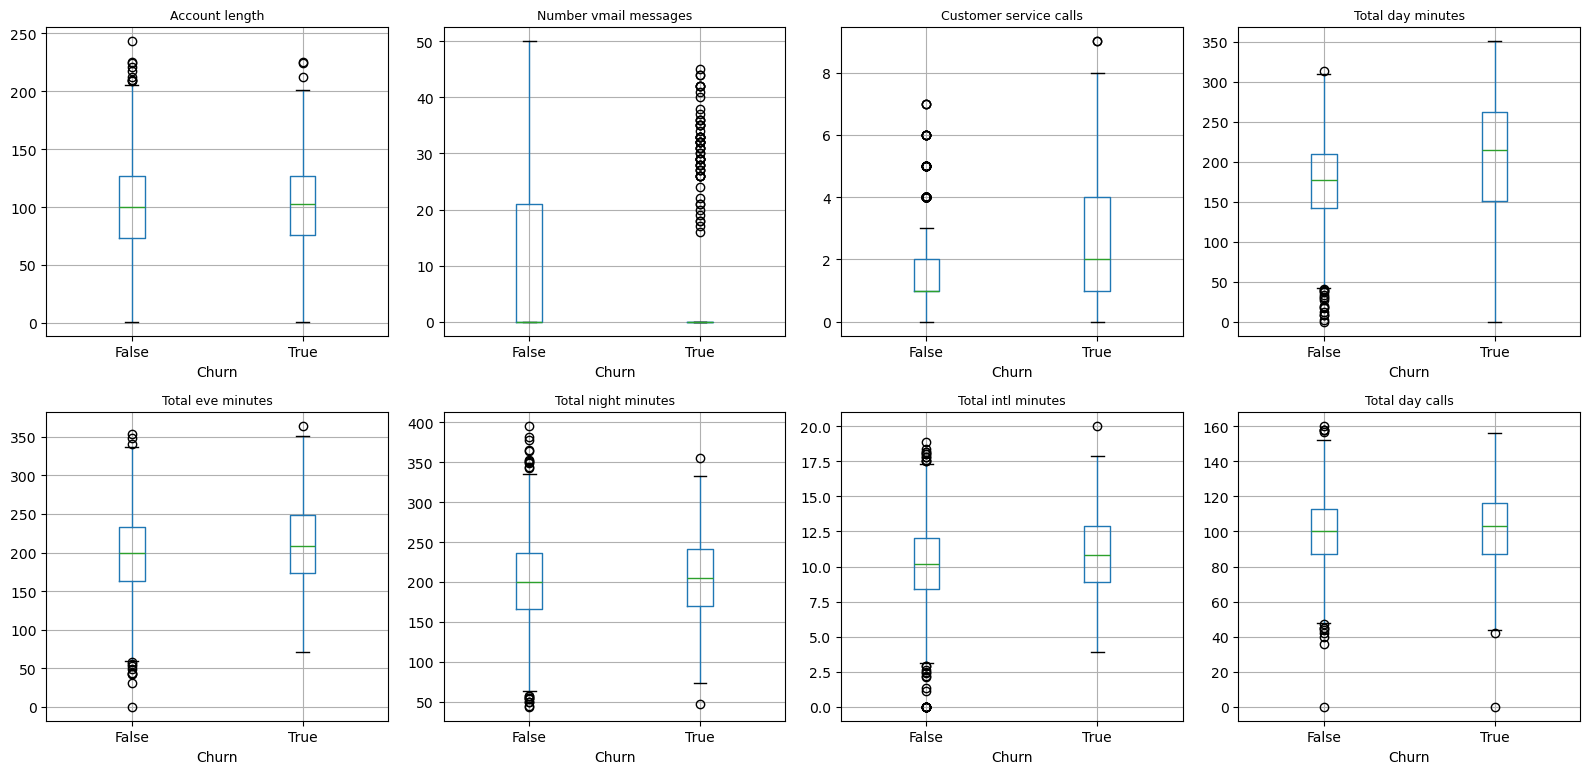

In [15]:
num_cols = [
    'Account length', 'Number vmail messages', 'Customer service calls',
    'Total day minutes', 'Total eve minutes', 'Total night minutes',
    'Total intl minutes', 'Total day calls'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))       # 2×4 subplot-grid
for ax, col in zip(axes.flatten(), num_cols):
    df.boxplot(column=col, by='Churn', ax=ax)          # boxplot per Churn-gruppe
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('Churn')
plt.suptitle('')                                       # fjern automatisk supertittel fra boxplot
plt.tight_layout()
plt.show()

**TOLKNING (kontinuerlige prediktorer):**  
`Customer service calls` viser tydeligst forskjell — kunder som churner ringer kundeservice markant oftere (høyere median og mer spredt fordeling). `Total day minutes` er også forskjellig: churners bruker gjennomsnittlig mer dagtid. `Account length`, `Total eve minutes`, `Total night minutes` og `Total intl minutes` viser mindre tydelige forskjeller mellom gruppene. `Total day calls` har nær identisk fordeling — antall samtaler alene er ikke en god prediktor.

## 3. Datapreprosessering

In [16]:
# Dropp State (50 nivåer) og charge-kolonner (perfekt korrelert med minutes)
df_model = df.drop(columns=[
    'State',
    'Total day charge',
    'Total eve charge',
    'Total night charge',
    'Total intl charge'
])

df_model['Churn'] = df_model['Churn'].astype(int)     # True/False → 1/0

# Lag dummyvariabler for kategoriske kolonner; drop_first unngår perfekt multikollinearitet
# dtype=int forhindrer bool-kolonner som feiler i statsmodels
df_model = pd.get_dummies(
    df_model,
    columns=['Area code', 'International plan', 'Voice mail plan'],
    drop_first=True,
    dtype=int
)

print(df_model.shape)
df_model.head()

(2666, 16)


,Account length,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn,Area code_415,Area code_510,International plan_Yes,Voice mail plan_Yes
0,128,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0,1,0,0,1
1,107,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0,1,0,0,1
2,137,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0,1,0,0,0
3,84,0,299.4,71,61.9,88,196.9,89,6.6,7,2,0,0,0,1,0
4,75,0,166.7,113,148.3,122,186.9,121,10.1,3,3,0,1,0,1,0


In [17]:
np.random.seed(123)                                           # reproduserbarhet
n = len(df_model)
train_idx = np.random.choice(n, size=n // 2, replace=False)  # tilfeldig 50 % til treningssett

train = df_model.iloc[train_idx]
test  = df_model.drop(train_idx)                              # resterende 50 % til testsett

y_train = train['Churn']
X_train = train.drop(columns='Churn')

y_test = test['Churn']
X_test = test.drop(columns='Churn')

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Churn rate train: {y_train.mean():.4f}, test: {y_test.mean():.4f}')

Train: (1333, 15), Test: (1333, 15)
Churn rate train: 0.1508, test: 0.1403


## 4. Modellering

### 4a. Logistisk regresjon

In [18]:
X_train_c = sm.add_constant(X_train)   # legg til konstantledd (intercept) for statsmodels
X_test_c  = sm.add_constant(X_test)

# GLM med Binomial-familie = logistisk regresjon (sigmoid link)
logreg = sm.GLM(y_train, X_train_c, family=sm.families.Binomial()).fit()
print(logreg.summary())                # viser koeffisienter, p-verdier og konfidensintervaller

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Churn   No. Observations:                 1333
Model:                            GLM   Df Residuals:                     1317
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -442.88
Date:                Mon, 18 May 2026   Deviance:                       885.76
Time:                        18:11:15   Pearson chi2:                 1.26e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1678
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -7

In [19]:
prob_lr = logreg.predict(X_test_c)              # predikerte sannsynligheter P(Churn=1)
pred_lr = (prob_lr > 0.5).astype(int)           # klassifiser: sannsynlighet > 0.5 → churn

accuracy_lr = (pred_lr == y_test).mean()        # andel korrekte prediksjoner
error_lr    = 1 - accuracy_lr                   # feilrate
print(f'Logistisk regresjon — Accuracy: {accuracy_lr:.4f}, Error rate: {error_lr:.4f}')

# Confusion matrix: rader = faktisk, kolonner = predikert
cm_lr = pd.crosstab(y_test, pred_lr, rownames=['Actual'], colnames=['Predicted'])
print(cm_lr)

Logistisk regresjon — Accuracy: 0.8672, Error rate: 0.1328
Predicted     0   1
Actual             
0          1113  33
1           144  43


**TOLKNING:**  
Signifikante prediktorer (p < 0.05): `Customer service calls`, `International plan_Yes`, `Total day minutes`, `Total intl calls`, `Total intl minutes`, `Voice mail plan_Yes`, `Total night minutes`, `Number vmail messages` og `Total eve minutes`. Accuracy = 86.7 % — kun marginalt bedre enn den naive modellen (85.97 %). Av 187 faktiske churners i testsettet fanges kun **43 opp** (23 % recall) — modellen er for forsiktig med å predikere churn.

### 4b. LDA

In [20]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)              # estimerer klassegjennomsnitt og felles kovariansmatrise
pred_lda = lda.predict(X_test)         # klassifiser testobservasjoner

accuracy_lda = (pred_lda == y_test).mean()
error_lda    = 1 - accuracy_lda
print(f'LDA — Accuracy: {accuracy_lda:.4f}, Error rate: {error_lda:.4f}')

cm_lda = pd.crosstab(y_test, pred_lda, rownames=['Actual'], colnames=['Predicted'])
print(cm_lda)

LDA — Accuracy: 0.8710, Error rate: 0.1290
Predicted     0   1
Actual             
0          1105  41
1           131  56


**TOLKNING:**  
LDA gir accuracy = 87.1 % — marginalt bedre enn logistisk regresjon (86.7 %). Viktigere: LDA fanger **56 av 187 churners** (30 % recall) mot 43 for logReg — noe bedre, men fortsatt svakt. LDA antar normalfordeling innen hver klasse, noe som er diskutabelt for variabler som `Customer service calls` (diskret, skjev fordeling).

### 4c. Random Forest

In [21]:
p = X_train.shape[1]                              # antall prediktorer

rf = RandomForestClassifier(
    max_features=int(np.sqrt(p)),                 # standard RF: sqrt(p) features per split
    n_estimators=100,                             # 100 trær
    random_state=123
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

accuracy_rf = (pred_rf == y_test).mean()
error_rf    = 1 - accuracy_rf
print(f'Random Forest — Accuracy: {accuracy_rf:.4f}, Error rate: {error_rf:.4f}')

cm_rf = pd.crosstab(y_test, pred_rf, rownames=['Actual'], colnames=['Predicted'])
print(cm_rf)

# Feature importance: gjennomsnittlig reduksjon i Gini-urenhet per variabel
importances = pd.DataFrame(
    {'importance': rf.feature_importances_},
    index=X_train.columns
).sort_values('importance', ascending=False)
print('\nFeature importance (topp 8):')
print(importances.head(8).round(4))

Random Forest — Accuracy: 0.9325, Error rate: 0.0675
Predicted     0    1
Actual              
0          1135   11
1            79  108

Feature importance (topp 8):
                        importance
Total day minutes           0.2215
Customer service calls      0.1423
Total eve minutes           0.0929
Total intl minutes          0.0818
International plan_Yes      0.0692
Total night minutes         0.0663
Total day calls             0.0582
Total intl calls            0.0549


**TOLKNING:**  
Random Forest gir accuracy = 93.3 % og fanger **108 av 187 churners** (57.8 % recall) — klart best på begge mål. De viktigste prediktorene er `Total day minutes` (22 %), `Customer service calls` (14 %), `Total eve minutes` (9 %), `Total intl minutes` (8 %) og `International plan_Yes` (7 %). Dette er konsistent med funnene fra deskriptiv statistikk og de signifikante variablene i logistisk regresjon. RF fanger ikke-lineære sammenhenger som de lineære modellene ikke klarer.

## 5. Sammenligning av modeller

In [22]:
results = pd.DataFrame({
    'Modell':     ['Naiv (alltid False)', 'Logistisk regresjon', 'LDA', 'Random Forest'],
    'Accuracy':   [1 - y_test.mean(), accuracy_lr, accuracy_lda, accuracy_rf],
    'Error rate': [y_test.mean(), error_lr, error_lda, error_rf]
})
results = results.sort_values('Error rate').reset_index(drop=True)

# Grønn markering på beste modell (lavest error / høyest accuracy)
results.style.highlight_min(subset=['Error rate'], color='lightgreen') \
             .highlight_max(subset=['Accuracy'],   color='lightgreen')

,Modell,Accuracy,Error rate
0,Random Forest,0.932483,0.067517
1,LDA,0.870968,0.129032
2,Logistisk regresjon,0.867217,0.132783
3,Naiv (alltid False),0.859715,0.140285


**KONKLUSJON:**  
**Beste modell:** Random Forest (accuracy 93.3 %, error rate 6.75 %). Logistisk regresjon og LDA er tilnærmet like og kun marginalt bedre enn den naive modellen (85.97 % accuracy). For churn er **recall** viktigere enn overall accuracy — det er kostbart å ikke identifisere churners: RF fanger 108/187 churners, mot 56/187 for LDA og 43/187 for logistisk regresjon. **Viktigste prediktorer på tvers av modeller:** `Total day minutes`, `Customer service calls` og `International plan` — konsistente funn fra deskriptiv statistikk, p-verdier og feature importance.